# **1. Perkenalan Dataset**


 **Sumber Dataset**:(*https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset*):
 Dataset berasal dari kaggle yang berisi data biaya asuransi medis untuk 1.338 individu, mencakup informasi demografis dan kesehatan seperti usia, jenis kelamin, BMI, jumlah anak, status merokok, serta wilayah tempat tinggal di AS. Variabel targetnya adalah charges, yaitu biaya asuransi yang dibebankan kepada setiap individu.

Kolom:
- age: usia
- sex: jenis kelamin
- bmi: indeks massa tubuh
- children: jumlah tanggungan
- smoker: status merokok
- region: wilayah AS
- charges: biaya asuransi


# **2. Import Library**

In [6]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# **3. Memuat Dataset**

In [7]:
# load dataset
data = pd.read_csv("../insurance.csv")

In [8]:
# show 5 baris pertama dataset
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
# show 5 baris terakhir dataset
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [10]:
print(data.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
print(data.duplicated().sum())

1


In [12]:
for col in data.select_dtypes(include=['object']).columns:
    print(data[col].value_counts(), "\n")

sex
male      676
female    662
Name: count, dtype: int64 

smoker
no     1064
yes     274
Name: count, dtype: int64 

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64 



<Axes: >

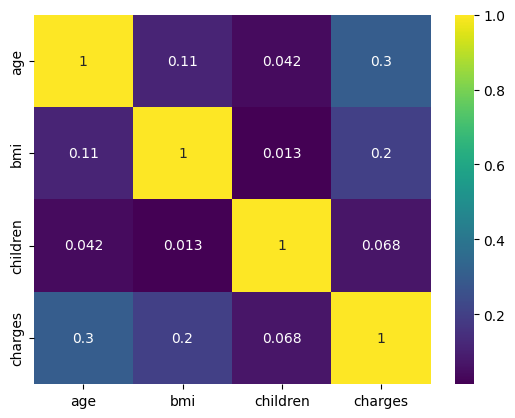

In [13]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='viridis')

In [14]:
print("\n=== Rata-rata Biaya berdasarkan Status Perokok ===")
print(data.groupby("smoker")["charges"].mean())

print("\n=== Rata-rata Biaya berdasarkan Wilayah ===")
print(data.groupby("region")["charges"].mean())

print("\n=== Rata-rata Biaya berdasarkan Jumlah Anak ===")
print(data.groupby("children")["charges"].mean())


=== Rata-rata Biaya berdasarkan Status Perokok ===
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

=== Rata-rata Biaya berdasarkan Wilayah ===
region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

=== Rata-rata Biaya berdasarkan Jumlah Anak ===
children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [15]:
# copy dataframe
df = data.copy()

In [16]:
# delete missing values
df = df.dropna()

In [17]:
# delete data duplikat
df = df.drop_duplicates()

In [18]:
# normalisasi / standarisasi fitur
categirical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns
target_col = 'charges'

numerical_cols = numerical_cols.drop(target_col)

scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


In [19]:
# mengatasi outlier
for feature in numerical_cols:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

In [20]:
# encode data kategorikal
df = pd.get_dummies(df, columns=categirical_cols,dtype=int)